Step 2 : Data Analysis

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the fresh, prepared data
df = pd.read_csv(r'c:\Users\moham\Desktop\BeCode\becode_projects\immo-eliza\data\processed\cleaned_data.csv')

# Verify the health of the data
print(df.shape)
df.head()




(23127, 19)


,locality,region,zip_code,property_type,subtype,price_eur,type_of_sale,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool,state_of_building
0,9000 Gent,Flanders,9000,House,Mixed Building,"2,200,000.00",for sale,6,"1,285.00",0,0,0,0.00,0,0.00,NaN,NaN,0,Fully renovated
1,1350 Orp-le-Grand,Wallonia,1350,House,Residence,"488,652.00",for sale,4,219.00,0,0,0,0.00,1,"1,127.00","1,221.00",3.00,0,New
2,6560 Erquelinnes,Wallonia,6560,House,Villa,"365,000.00",for sale,4,281.00,0,0,1,NaN,1,NaN,"5,639.00",4.00,0,NaN
3,5570 Felenne,Wallonia,5570,House,Cottage,"118,000.00",for sale,2,110.00,0,0,1,NaN,1,NaN,733.00,NaN,0,NaN
4,7130 Bray,Wallonia,7130,House,Residence,"325,641.00",for sale,4,210.00,0,0,0,0.00,1,538.00,618.00,3.00,0,New


In [66]:
#It tells Pandas: "Stop using 'e' notation 
# and just show me two decimal places for all floats."
pd.options.display.float_format = '{:,.2f}'.format

1. How many rows and columns?

In [67]:
df.shape

(23127, 19)

2. How are variables correlated to each other? (Why?)

In [68]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,zip_code,price_eur,num_rooms,living_area_m2,fully_equipped_kitchen,furnished,terrace,terrace_area_m2,garden,garden_area_m2,land_surface_m2,num_facades,swimming_pool
zip_code,1.00,-0.16,0.03,0.04,-0.05,0.05,-0.06,-0.01,0.14,0.00,0.04,0.09,0.01
price_eur,-0.16,1.00,0.48,0.51,0.07,0.02,0.12,0.22,0.15,0.10,0.29,0.22,0.26
num_rooms,0.03,0.48,1.00,0.58,0.04,-0.01,0.03,0.11,0.27,0.07,0.22,0.21,0.12
living_area_m2,0.04,0.51,0.58,1.00,0.04,-0.02,0.00,0.18,0.21,0.12,0.30,0.22,0.17
fully_equipped_kitchen,-0.05,0.07,0.04,0.04,1.00,0.03,0.16,0.09,0.03,0.02,0.01,-0.04,0.05
furnished,0.05,0.02,-0.01,-0.02,0.03,1.00,0.02,0.02,-0.05,0.01,0.02,0.01,0.05
terrace,-0.06,0.12,0.03,0.00,0.16,0.02,1.00,0.31,0.09,0.02,0.00,-0.03,0.07
terrace_area_m2,-0.01,0.22,0.11,0.18,0.09,0.02,0.31,1.00,0.11,0.05,0.12,0.12,0.17
garden,0.14,0.15,0.27,0.21,0.03,-0.05,0.09,0.11,1.00,0.08,0.16,0.32,0.12
garden_area_m2,0.00,0.10,0.07,0.12,0.02,0.01,0.02,0.05,0.08,1.00,0.26,0.06,0.06


<Figure size 1000x800 with 0 Axes>

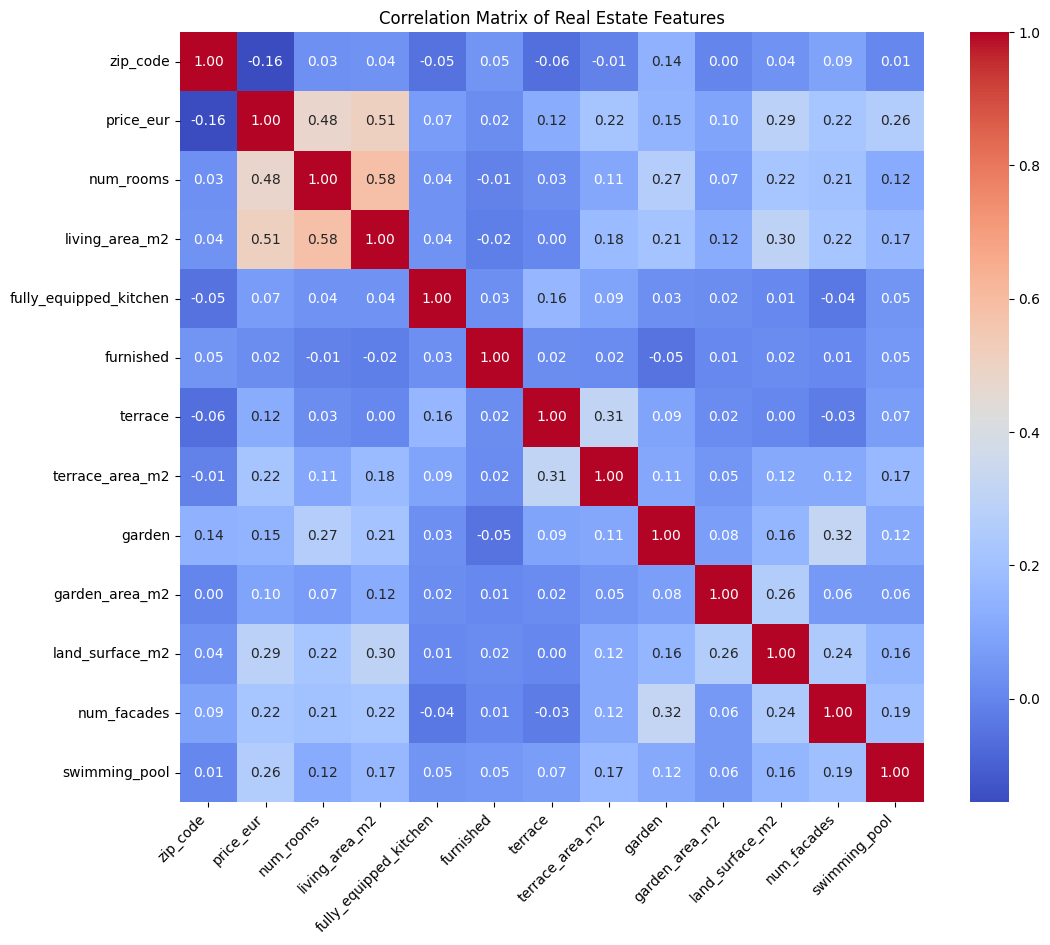

In [125]:

plt.figure(figsize=(10, 8))
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation Matrix of Real Estate Features')
plt.show()


What is the correlation between the variables and the price? (Why might that be?)

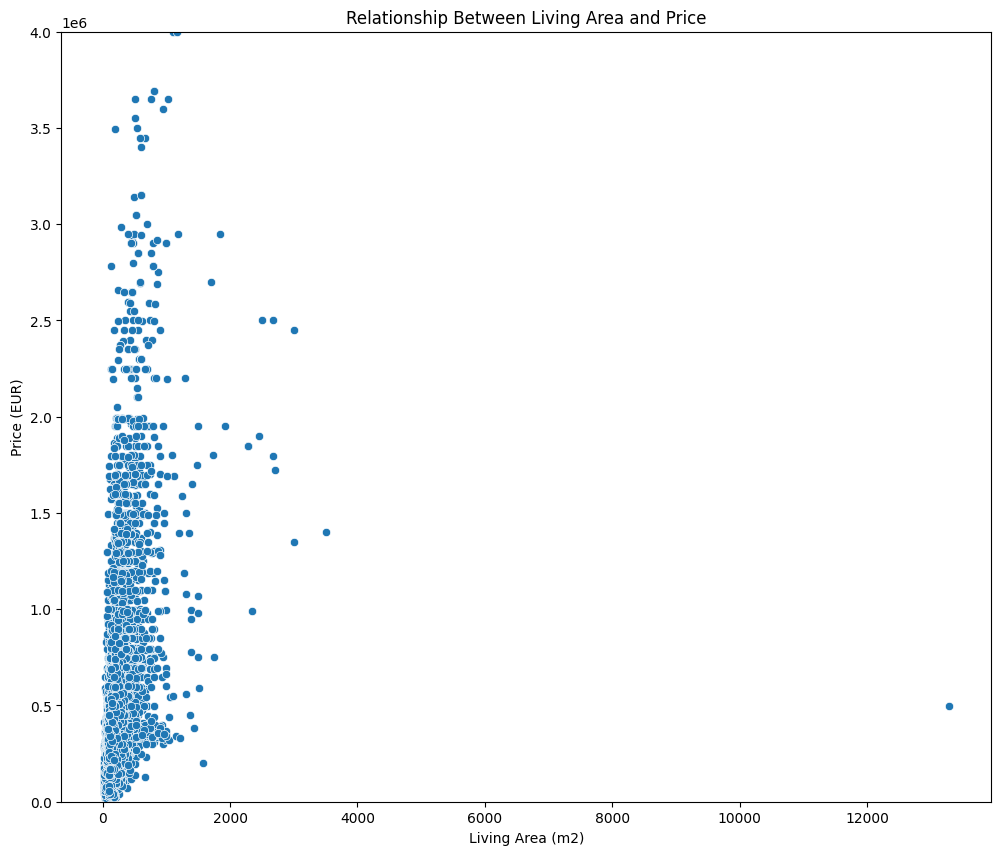

In [70]:
# Step 1: Set the size of the drawing
plt.figure(figsize=(12, 10))
# Step 2: Create the scatter plot
sns.scatterplot(data=df ,x='living_area_m2', y='price_eur')
# Step 3: Handling Outliers (The Viewport)
# We limit the vertical axis to 4 million to see the majority of houses clearly
plt.ylim(0, 4000000)
# Step 4: Decoration
plt.title('Relationship Between Living Area and Price')
plt.xlabel('Living Area (m2)')
plt.ylabel('Price (EUR)')
# Step 5: Render
plt.show()

Using a Scatterplot:
You have successfully generated your first Bivariate Analysis (analyzing two variables at once).The "narrow straight line" you see is the visual proof of your correlation coefficient. 
However, look closely at your plot. 
Notice how as the $x$-axis (Living Area) increases, the dots start to "fuzz" or spread out a bit more? This is the birth of Variance.

1. Analysis: The "Sync" and the "Why"
The "What": You are seeing a Linear Relationship.
The "Why": Because the cost of building or buying a property is often calculated "per square meter." 
If the average price is, say, €2,500/m2, then a 100m2 house will be roughly €250,000 and a 200m2 house will be €500,000. They move in a straight line because the multiplier is relatively consistent.

2. Why might there be a "fuzz" (Vertical spread)?
Even if two houses are both 150m2, one might be in the center of Brussels (Expensive) and the other in a rural village (Cheap). 
That vertical gap between two dots at the same x-coordinate is the influence of other variables (like Locality or State of Building).

3. Which variables have the greatest influence on the price?

4. Which variables have the least influence on the price?

price_correlations=living_area_m2           0.51
num_rooms                0.48
land_surface_m2          0.29
swimming_pool            0.26
num_facades              0.22
terrace_area_m2          0.22
garden                   0.15
terrace                  0.12
garden_area_m2           0.10
fully_equipped_kitchen   0.07
furnished                0.02
Name: price_eur, dtype: float64


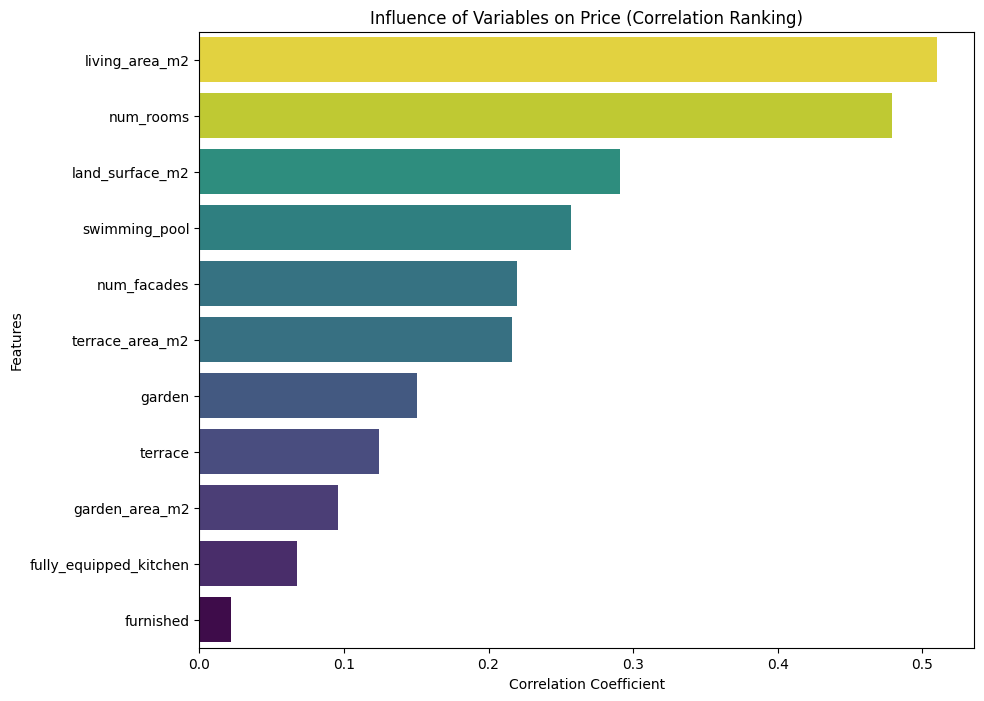

In [71]:
# 1. Isolate the 'price_eur' column from the correlation matrix
# and sort the values so the highest is at the top
# 2. We remove 'price_eur' itself (because it's always 1.0)
price_correlations = df.corr(numeric_only=True)['price_eur'].sort_values(ascending=False).drop('price_eur').drop('zip_code')
print(f"{price_correlations=}")

# 3. Setup the drawing
plt.figure(figsize=(10, 8))

# 4. Create the bar plot
# We use the 'index' (column names) for the Y axis 
# and the 'values' (the correlation numbers) for the X axis
sns.barplot(x=price_correlations.values, y=price_correlations.index, palette='viridis', hue=price_correlations, legend=False)

# 5. Add labels
plt.title('Influence of Variables on Price (Correlation Ranking)')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

plt.show()


Top variables that have the least influence on the price:
1. living_area_m2
2. num_rooms
3. land_surface_area

Bottom variables that have the least influence on the  price:
1. fully_equipped_kitchen
2. furnished

How would you transform these values into numerical values?

A. One-Hot Encoding (The "Lego" System)

For variables with no natural order (e.g., property_type, region), we create new columns for each category.

The Intuition: Instead of one column called Region with "Flanders", we create three columns: is_Flanders, is_Wallonia, is_Brussels.

The Mechanics: For each row, only one of these columns gets a 1, the others get 0. This allows the model to see each region as a separate "on/off" switch.

B. Ordinal Encoding (The "Ladder" System)

For variables that have a logical rank (e.g., state_of_building), we assign a number based on quality.

The Intuition: "To be renovated" is lower than "Just renovated."

The Mechanics: We map the labels to a scale:

To be renovated -> 1

Good -> 2 

Excellent -> 3


USE KLITI'S NUMBERING SYSTEM
SEE BELOW


In [ ]:
df['state_of_building'].unique() #check unique values
state_order = {                  #assign values based on buildind state
    'To demolish': 1,
    'To restore': 2,
    'To renovate': 3,
    'To be renovated': 4,
    'Normal': 5,
    'Under construction': 6,
    'Fully renovated': 7,
    'Excellent': 8,
    'New': 9
}
df['building_state_encoded'] = df['state_of_building'].map(state_order)


Percentage of missing values per column?


In [72]:
# Missing value report percentage per column
missing_report = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("---Percentage of Missing Values---")
missing_report[missing_report > 0].sort_values(ascending=False)

---Percentage of Missing Values---


garden_area_m2      34.31
terrace_area_m2     32.46
num_facades         21.72
state_of_building   20.79
land_surface_m2      7.90
dtype: float64

Step 3: Data Interpretation

HOW TO ACTUALLY SPOT OUTLIERS?

1. The "First Glance" Diagnostic: .describe()

You have already used df.describe(). To find outliers, you look at three specific numbers for your quantitative columns: Mean, 50% (Median), and Max.

- The Red Flag: If the Mean is significantly higher than the 50% (Median), your data is right-skewed. This means a few "Giant" numbers are pulling the average up.
- The "Impossible" Max: Look at the Max. Does it make sense in the real world?Example: If living_area_m2 has a Max of 10,000 $m^2$, that’s a palace, not a house. That is a confirmed outlier.
 
2. The Statistical Diagnostic: The IQR Rule

Statistically, an outlier is officially defined by the Interquartile Range (IQR). You can calculate this for every numeric column without drawing a single plot.

- Find the "Inner 50%": This is the distance between the 25th percentile (Q1) and the 75th percentile (Q3).
- Set the "Fences": Any number more than 1.5 times the IQR away from the box is an outlier.


In [73]:
#1. The "First Glance" Diagnostic: .describe()

df['price_eur'].describe()

count      23,127.00
mean      399,286.59
std       325,555.25
min        14,999.00
25%       229,712.50
50%       329,000.00
75%       458,316.50
max     8,900,000.00
Name: price_eur, dtype: float64

1. The Mean vs. Median: The €70,000 Gap
You said the mean ($399,286$) is not "significantly" higher than the median ($329,000$). In data science, "significant" is relative.

- The Math: Your mean is roughly 21% higher than your median.
- The Reality: That is a €70,286 difference. In the Belgian housing market, €70k is the price of a high-end renovation or a significant down payment.
- The Verdict: If the mean and median were close, the difference would be maybe 2–5%. A 21% gap is a loud "Red Flag." It tells us that while the "middle" house is €329k, there are enough multi-million euro mansions to pull the average up by €70,000 for everyone.

How to "see" it: Imagine 10 people in a bar. 9 of them earn €30k/year. 1 of them is a billionaire.

- Median: €30k (The "typical" person).
- Mean: €100 Million (The "average" person).
- The mean lied to you about the bar's population; the median told the truth.

In [74]:
#2. The Statistical Diagnostic: The IQR Rule

# Calculate Q1, Q3 and IQR
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

# Define anything outside of (Q1 - 1.5*IQR) and (Q3 + 1.5*IQR) as True
outliers = (df.select_dtypes(include=['number']) < (Q1 - 1.5 * IQR)) | (df.select_dtypes(include=['number']) > (Q3 + 1.5 * IQR))

# Sum them up to see which columns have the most "Freaks"
print(outliers.sum().sort_values(ascending=False))

garden_area_m2            2554
land_surface_m2           1890
price_eur                 1418
living_area_m2            1391
terrace_area_m2            938
swimming_pool              739
furnished                  627
num_rooms                  244
zip_code                     0
fully_equipped_kitchen       0
terrace                      0
garden                       0
num_facades                  0
dtype: int64


3. How to read your IQR Result
The numbers you got (e.g., price_eur: 1418) are the Count of Rows that crossed the "Statistical Fence."

- price_eur: 1418: This means 1,418 properties in your dataset are statistically "Extreme." They are either way too cheap or way too expensive compared to the rest of Belgium.

- garden_area_m2: 2554: This is your highest count. It means a lot of properties have gardens that are massive (think chateaus with parks) compared to the standard city garden.

PRICE OUTLIERS

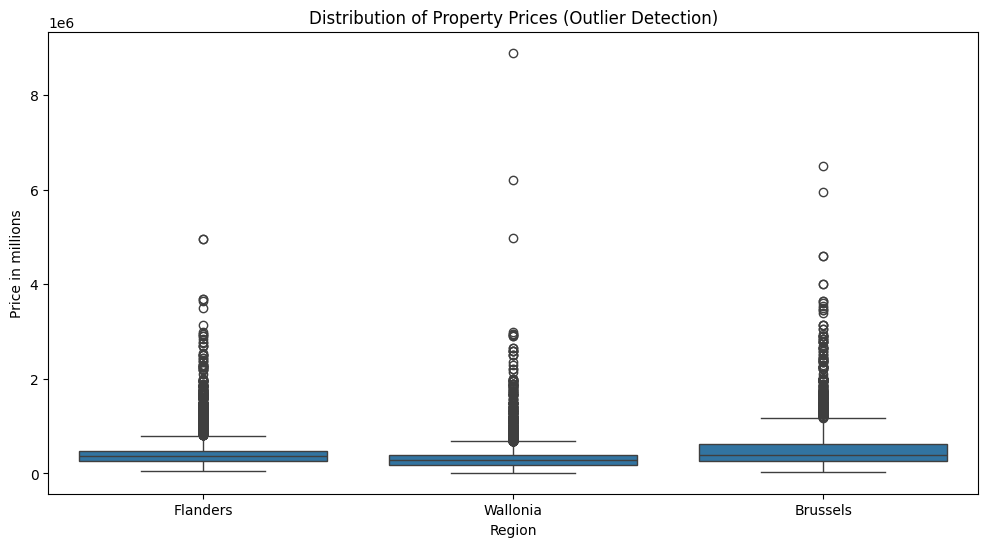

In [107]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))

# Create the plot
ax = sns.boxplot(data=df, x='region', y='price_eur')

# THE FIX: Format the X-axis with thousands separators (commas)
#ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Distribution of Property Prices (Outlier Detection)')
plt.xlabel('Region')
plt.ylabel('Price in millions')
plt.show()

1. Anatomy of a Boxplot (The Architecture)

Think of your 23,000 houses standing in a line from cheapest to most expensive. The boxplot divides that line into four equal groups (Quartiles).

- The Big Blue Box: This represents the middle 50% of your data. This is the "Heart" of the market.
- The Fine Line in the Middle of the box: This is the Median. It is the middle house. If you have 23,001 houses, this is the price of the 11,501st house.
- The Two Outer Lines (The Whiskers): These are the "Statistical Fences." They show the range of "Normal" prices.
  - The left whisker goes to the minimum "normal" price.
  - The right whisker goes to the maximum "normal" price (Q3 + 1.5 x IQR).
- The Dots: These are your Outliers. Each dot is a real property that is so expensive (or so cheap) that it sits outside the "Normal" statistical fence.

2. Your Critical Interpretation

Look at your plot again with the new scale:

The "Wall" of Dots: Notice how the dots start around €700k or €800k and go all the way to €6,000,000.

The Decision: This visual confirms why we use the Median. In your plot, the median is that line around €330k. It stays there regardless of whether a castle is €5M or €50M. The Mean, however, is being dragged to the right by all those dots.

1. Are the dots the 1,418 properties from the IQR rule?

Exactly. The boxplot is the visual twin of the IQR rule. When you ran that code and it said price_eur: 1418, it was counting the points that sit outside the whiskers. Every dot you see in that plot is one of those 1,418 properties.

- The "Crowd": Notice how the dots are very thick near the whisker and get thinner as they move right. This shows that while we have many €1M houses, we have very few €6M houses.

2. What do we do with them? Delete now or later?

This is a strategic choice. In a professional workflow, we handle them differently depending on the "Mode":

- Mode: Analysis (Right now): DO NOT DELETE THEM. 
  
  - Why? Your mission asks: "What are the most expensive municipalities?". If you delete the €5,000,000 mansions, you are literally deleting the "Most Expensive" data. Your analysis would be fake because you removed the very thing you were looking for.

  - Solution: We keep the data but we use the Median instead of the Mean in our reports, because the Median ignores these "freak" numbers.

- Mode: Machine Learning (Step 4 - Future): DELETE OR TRANSFORM THEM.

  - Why? Models like Linear Regression try to "please" every dot. If you have one house at €10M, the model will tilt its whole "logic" to try and reach that dot, making its predictions for normal €300k houses less accurate.

  - Conclusion: For now, keep them. We are in "Exploration Mode."

LIVING AREA OUTLIERS 

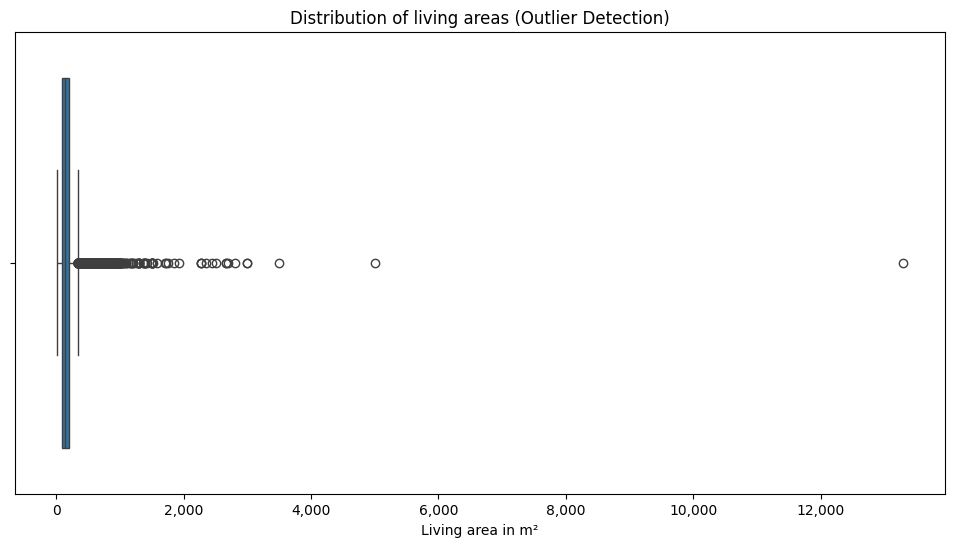

In [76]:
plt.figure(figsize=(12, 6))

# Create the plot
ax = sns.boxplot(data=df, x='living_area_m2')

# THE FIX: Format the X-axis with thousands separators (commas)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Distribution of living areas (Outlier Detection)')
plt.xlabel('Living area in m²')
plt.show()

LAND SURFACE OUTLIERS


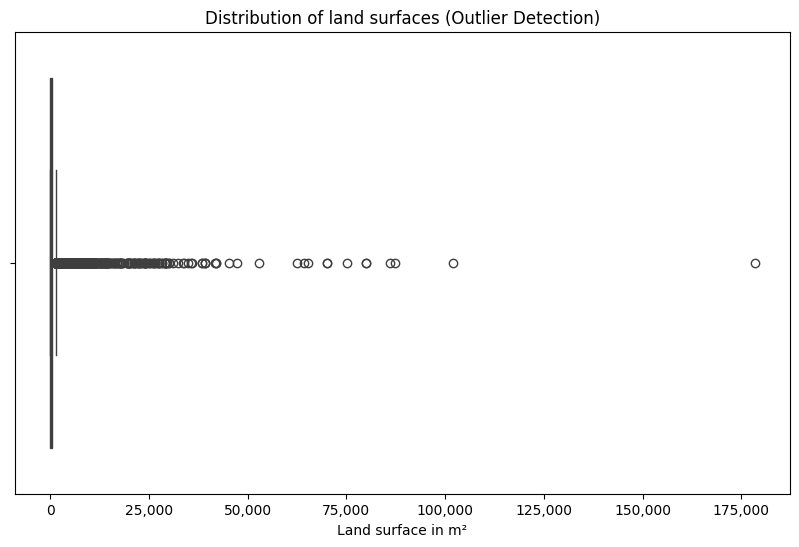

In [77]:
plt.figure(figsize=(10, 6))

# Create the plot
ax = sns.boxplot(data=df, x='land_surface_m2')

# THE FIX: Format the X-axis with thousands separators (commas)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Distribution of land surfaces (Outlier Detection)')
plt.xlabel('Land surface in m²')
plt.show()

In [78]:
# Look at the 5 properties with the largest living area
print(df.nlargest(5, 'living_area_m2')[['locality', 'property_type', 'living_area_m2', 'price_eur']])

            locality property_type  living_area_m2    price_eur
2652     9881 Bellem         House       13,289.00   495,000.00
21361  6010 Couillet         House        5,000.00 8,900,000.00
9678     5640 Mettet         House        3,500.00 1,400,000.00
8395       7540 Kain         House        3,000.00 1,350,000.00
11432      3806 Velm         House        3,000.00 2,450,000.00


1. The Bellem Case: Detective Verdict
   
   Your detective work on the Bellem property ($13,289 m^2$ for €495,000) is crucial. Let’s look at the math: that is €37 per square meter. Even in rural Belgium, a finished house costs at least €1,500–€2,500 per $m^2$ to build.
   
   Verdict: This is an Error Outlier (Typo). The person likely entered the land surface (garden/lot size) into the "Living Area" box by mistake.
   
      - The Rule: You should delete this specific row (or any where $m^2 > 2000$ and price is low) because it will "poison" your future model with fake information.

Represent the number of properties according to their surface using a histogram.

Now we move to the Histogram. This answers: "Is Belgium a country of small apartments or massive villas?"

The Challenge: The "Long Tail"

If you plot all $m^2$, that Bellem error ($13,000 m^2$) will force the horizontal axis to be so long that 99% of your houses will be squashed into a tiny single line at the start.The 

Solution: Filtering for Visualization

To make a readable chart, we temporarily "zoom in" on the normal range (houses under $1,000 m^2$).

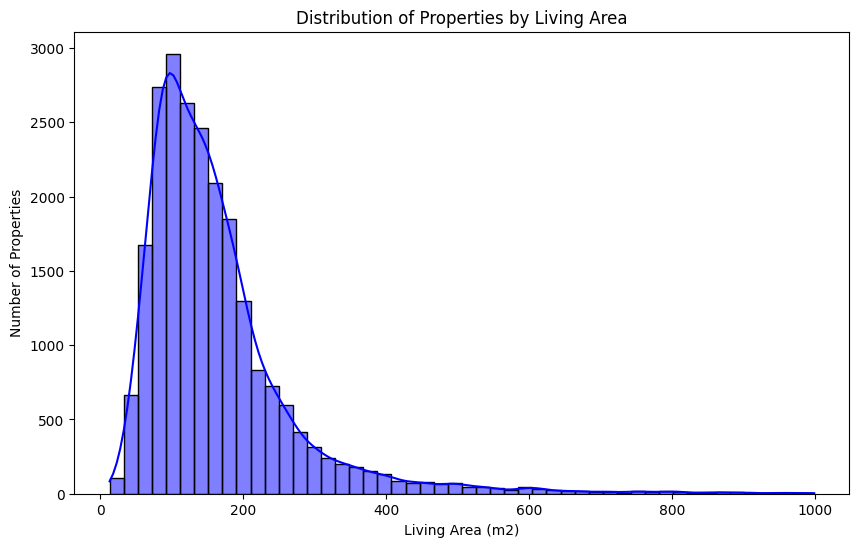

In [127]:
plt.figure(figsize=(10, 6))

# We filter the data just for this plot to see the 'Normal' market
# To make a readable chart, we temporarily "zoom in" 
# on the normal range (houses under 1,000 m2).
# Create the histogram of living_area_m2
sns.histplot(df[df['living_area_m2'] < 1000]['living_area_m2'], bins=50, kde=True, color='blue')

# Add the labels
plt.title('Distribution of Properties by Living Area')
plt.xlabel('Living Area (m2)')
plt.ylabel('Number of Properties')

plt.show()

1. Analysis: The "Peak" and the "KDE"
   - The "Peak" (160 $m^2$): You are spot on. This is the Mode of your dataset. It tells us that the "typical" Belgian home isn't a tiny studio or a massive villa, but a comfortable family-sized space.
   - The "KDE" (The Curve): Your description of the "hump and slope" is perfect. In statistics, we call this Positive Skew (or Right-Skewed).The 

     - "Why": There is a physical limit to how small a house can be (you can't live in $0 m^2$), so the left side is cut off. But there is no limit to how big a house can be, so the "tail" stretches out to the right.

2. Finding the "Golden Range" for Histograms

A common rule of thumb in data science to see the "heart" of the data is to look at the 99th Percentile. 

This means we show the 99% of houses that are "normal" and ignore the 1% that are "extreme" (like the Bellem house).

The Quick Research Calculation:
Run this in a cell to find where the 99% cutoff is:


In [80]:
cutoff = df['living_area_m2'].quantile(0.99)
print(f"99% of properties are smaller than: {cutoff} m2")

99% of properties are smaller than: 660.7400000000016 m2


CREATING PRICE PER SQUARE METER COLUMN

2. Building the "Master Table"
Instead of writing separate code for every question, we will create a Summary Table that answers everything at once. 

This is the most efficient way to handle the "Belgium vs. Wallonia vs. Flanders" comparison.

In [90]:
# 1. Create the unit price column for every house
df['price_per_m2'] = (pd.to_numeric(df['price_eur']) / pd.to_numeric(df['living_area_m2'])).round(2)
cols = list(df.columns)
cols.insert(cols.index('living_area_m2') + 1, cols.pop(cols.index('price_per_m2')))
df = df[cols]

# 2. Define the columns we want to calculate
metrics = {
    'price_eur': ['mean', 'median'],
    'price_per_m2': 'mean' # This gives us the average price/m2 for the town
}

# 3. Create the grouped analysis for ALL localities
mun_stats = df.groupby(['region', 'locality']).agg(metrics)

# 4. Flatten the columns to make them readable
mun_stats.columns = ['mean_price', 'median_price', 'avg_price_m2']
mun_stats['count'] = df.groupby(['region', 'locality']).size()

# 5. Filter for at least 5 listings to stay accurate
mun_stats = mun_stats[mun_stats['count'] >= 5]

What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)


In [94]:
# A. Most Expensive in Belgium
print("--- TOP 5 MOST EXPENSIVE IN BELGIUM ---")
print(mun_stats.sort_values('median_price', ascending=False).head(5))

--- TOP 5 MOST EXPENSIVE IN BELGIUM ---
                             mean_price  median_price  avg_price_m2  count
region   locality                                                         
Flanders 1950 Kraainem     1,069,244.44    995,000.00      4,254.23     36
         8300 Knokke-Heist   874,555.66    865,000.00      8,723.07     53
         1933 Sterrebeek   1,035,171.43    849,000.00      4,772.55     35
         8300 Knokke       1,090,371.79    795,000.00     10,103.21     39
         3040 Neerijse       939,000.00    795,000.00      2,708.53      5


What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

In [97]:
print("\n--- 5 LEAST EXPENSIVE IN BELGIUM ---")
print(mun_stats.sort_values('median_price', ascending=True).head(5))


--- 5 LEAST EXPENSIVE IN BELGIUM ---
                                 mean_price  median_price  avg_price_m2  count
region   locality                                                             
Wallonia 5542 Blaimont            87,190.48     65,500.00      1,543.38     21
         6464 Forges             143,526.67     69,000.00      1,435.06      6
         5541 Hastière-par-delà  309,428.57     85,000.00      1,544.05      7
         6020 Dampremy           111,725.00     85,000.00      1,107.54      8
         5540 Hastière-Lavaux     91,721.43     86,950.00      1,524.77     14


What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [95]:
print("\n--- TOP 5 MOST EXPENSIVE IN WALLONIA ---")
print(mun_stats.xs('Wallonia', level='region').sort_values('median_price', ascending=False).head(5))


--- TOP 5 MOST EXPENSIVE IN WALLONIA ---
                                  mean_price  median_price  avg_price_m2  \
locality                                                                   
1421 Ophain-Bois-Seigneur-Isaac 1,226,062.50    747,500.00      3,278.04   
7880 Flobecq                      659,800.00    740,000.00      2,573.27   
1380 Lasne                        797,292.06    722,500.00      3,251.46   
1325 Chaumont-Gistoux             628,941.21    662,500.00      3,118.88   
7503 Froyennes                    592,375.00    660,000.00      2,224.66   

                                 count  
locality                                
1421 Ophain-Bois-Seigneur-Isaac      8  
7880 Flobecq                         5  
1380 Lasne                          48  
1325 Chaumont-Gistoux               24  
7503 Froyennes                       8  


What are the less expensive municipalities in Wallonia? (Average price, median price, price per square meter)

In [99]:
print("\n--- TOP 5 LEAST EXPENSIVE IN WALLONIA ---")
print(mun_stats.xs('Wallonia', level='region').sort_values('median_price', ascending=True).head(5))


--- TOP 5 LEAST EXPENSIVE IN WALLONIA ---
                        mean_price  median_price  avg_price_m2  count
locality                                                             
5542 Blaimont            87,190.48     65,500.00      1,543.38     21
6464 Forges             143,526.67     69,000.00      1,435.06      6
6020 Dampremy           111,725.00     85,000.00      1,107.54      8
5541 Hastière-par-delà  309,428.57     85,000.00      1,544.05      7
5540 Hastière-Lavaux     91,721.43     86,950.00      1,524.77     14


What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [100]:
flanders_stats = mun_stats.xs('Flanders', level='region')

print("\n--- 5 LEAST EXPENSIVE IN FLANDERS ---")
print(flanders_stats.sort_values('median_price', ascending=False).head(5))


--- 5 LEAST EXPENSIVE IN FLANDERS ---
                    mean_price  median_price  avg_price_m2  count
locality                                                         
1950 Kraainem     1,069,244.44    995,000.00      4,254.23     36
8300 Knokke-Heist   874,555.66    865,000.00      8,723.07     53
1933 Sterrebeek   1,035,171.43    849,000.00      4,772.55     35
8300 Knokke       1,090,371.79    795,000.00     10,103.21     39
3040 Neerijse       939,000.00    795,000.00      2,708.53      5


What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)

In [101]:
print("\n--- 5 LEAST EXPENSIVE IN FLANDERS ---")
print(flanders_stats.sort_values('median_price', ascending=True).head(5))


--- 5 LEAST EXPENSIVE IN FLANDERS ---
                mean_price  median_price  avg_price_m2  count
locality                                                     
8890 Moorslede  222,272.73    165,000.00      1,748.99     11
3870 Heers      198,666.67    192,000.00      1,331.29      6
8940 Wervik     208,313.90    199,000.00      1,197.59     29
8930 Menen      259,394.29    199,000.00      1,602.08     35
8580 Avelgem    305,538.46    215,000.00      2,398.93     13


TESTING OTHER QUESTIONS AND BUSINESS IDEAS



Segmentation of the "Middle Class": What is the "Sweet Spot" price range that has the highest volume of listings?

Business Problem: Optimizing the search engine. If 80% of listed properties are between €200k and €450k, the UI should be optimized for those "Golden Range" filters.

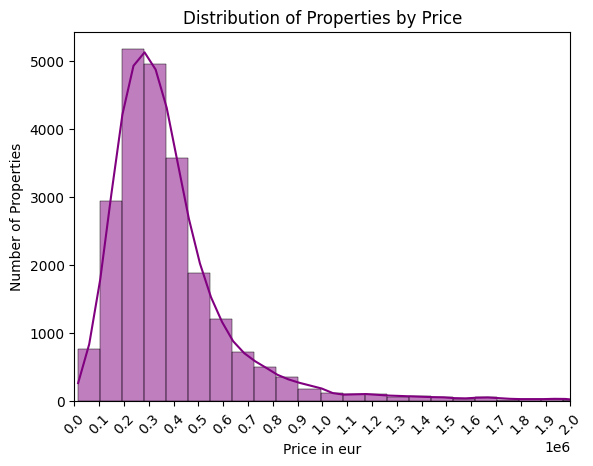

In [128]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Fixed the missing closing parenthesis here
sns.histplot(df['price_eur'], bins=100, kde=True, color='purple')

# You might want to update this title to 'Distribution of Properties by Price'
plt.title('Distribution of Properties by Price')
plt.xlabel('Price in eur')
plt.ylabel('Number of Properties')

# 1. Limit the x-axis to 2 million
plt.xlim(0, 2000000)

# 2. Set a tick every 100k (from 0 up to 2,000,000)
plt.xticks(np.arange(0, 2100000, 100000))

# 3. Rotate labels by 45 degrees so they are readable
plt.xticks(rotation=45)

plt.show()